In [1]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [2]:
NUMBER_OF_FLOWS = 50

STEPS = 5

INTERVAL_LENGTH = int(NUMBER_OF_FLOWS / STEPS)

SESSIONS = np.arange(0, NUMBER_OF_FLOWS, step=INTERVAL_LENGTH)

In [3]:
results_flows_directories = glob.glob("dados/results_flows_*/*")

In [4]:
results_flows_directories

['dados/results_flows_speed_15.0_50/dp_36_sfc_on_speed_15.0',
 'dados/results_flows_speed_15.0_50/musfico_36_sfc_on_speed_15.0',
 'dados/results_flows_speed_75.0_50/dp_36_sfc_on_speed_75.0',
 'dados/results_flows_speed_75.0_50/musfico_36_sfc_on_speed_75.0',
 'dados/results_flows_speed_45.0_50/musfico_36_sfc_on_speed_45.0',
 'dados/results_flows_speed_45.0_50/dp_36_sfc_on_speed_45.0',
 'dados/results_flows_speed_0.0_50/musfico_36_sfc_on_speed_0.0',
 'dados/results_flows_speed_0.0_50/dp_36_sfc_on_speed_0.0',
 'dados/results_flows_speed_30.0_50/musfico_36_sfc_on_speed_30.0',
 'dados/results_flows_speed_30.0_50/dp_36_sfc_on_speed_30.0',
 'dados/results_flows_speed_60.0_50/dp_36_sfc_on_speed_60.0',
 'dados/results_flows_speed_60.0_50/musfico_36_sfc_on_speed_60.0']

In [5]:

df = pd.DataFrame()

for alg_dir in results_flows_directories:
    files = os.listdir(alg_dir)
    simu_exec_name = alg_dir.split("/")[-1].split("_")
    alg_name = simu_exec_name[0]
    sfc = simu_exec_name[3]
    vel = simu_exec_name[-1]
    for idx, file in enumerate(files):
        data_path = os.path.join(alg_dir, file)
        try:
            simulation_df = pd.read_csv(data_path)
        except:
            continue

        simulation_df["algorithm"] = alg_name
        simulation_df["sfc"] = sfc
        simulation_df["speed"] = vel
        simulation_df["exec"] = idx

        df = pd.concat([df, simulation_df], axis=0)

In [6]:
def resource_utilization(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    resource_result = []
    for slice in slices:
        if len(slice) == 0:
            continue
        average_consumption = np.mean(slice)
        resource_result.append(average_consumption)

    return resource_result

In [7]:
grouped_df = df.groupby(["sfc", "algorithm", "speed", "exec"])

In [8]:
def format_resource_boxplot(df):
    df = pd.DataFrame(df)
    speeds = [x for x in np.unique(df.index.get_level_values("speed"))]
    algs = [x for x in np.unique(df.index.get_level_values("algorithm"))]
    dic = {}
    for alg in algs:
        d_velocitys = []
        for sp in speeds:
            ar = df.query("('{0}' == speed) & (algorithm == '{1}')".format(sp, alg))
            ar = ar.values.tolist()
            partitions = np.array_split(np.array(ar), 10)
            stacked_partitions = np.vstack(partitions)
            result = (np.sum(stacked_partitions, axis=0) / 10).ravel()
            d_velocitys.append(result)
        dic[str(alg)] = d_velocitys
    return pd.DataFrame(dic, index=speeds)

In [9]:
acceptance_series = grouped_df["success"].apply(resource_utilization)
bd_series = grouped_df["cache_utilization"].apply(resource_utilization)
cache_series = grouped_df["bandwidth_utilization"].apply(resource_utilization)
cpu_series = grouped_df["cpu_utilization"].apply(resource_utilization)

In [10]:
cpu = format_resource_boxplot(cpu_series)
bd = format_resource_boxplot(bd_series)
cache = format_resource_boxplot(cache_series)
acceptance = format_resource_boxplot(acceptance_series)

In [13]:
def plot_resource_boxplot(data_boxplot, fontsize=22):
    plt.figure(figsize=(20, 10))
    width = 5
    fontsize = fontsize

    data_a = data_boxplot["dp"].tolist()
    data_b = data_boxplot["musfico"].tolist()

    positions = [0, 15, 30, 45, 60, 75]

    boxes1 = plt.boxplot(
        data_a,
        notch=0,
        patch_artist=True,
        positions=positions,
        sym="",
        widths=width,
        zorder=3,
        flierprops={"markersize": 8},
    )
    boxes2 = plt.boxplot(
        data_b,
        notch=0,
        patch_artist=True,
        positions=[p + 3 for p in positions],
        sym="",
        widths=width,
        zorder=3,
        flierprops={"markersize": 8},
    )

    plt.grid(lw=2, zorder=0)
    plt.xticks(positions, ["0", "15", "30", "45", "60", "75"], fontsize=fontsize)
    plt.xlabel("speed(m/s)", fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.ylabel("ylabel", fontsize=fontsize)

    colors = ["#0000FF", "#FF0000"]

    for patch in boxes1["boxes"]:
        patch.set_facecolor(colors[0])
    for patch in boxes2["boxes"]:
        patch.set_facecolor(colors[1])

    plt.legend(
        [boxes1["boxes"][0], boxes2["boxes"][0]],
        ["MSF", "MUSFICO"],
        loc="upper right",
        fontsize=fontsize,
    )
    plt.show()

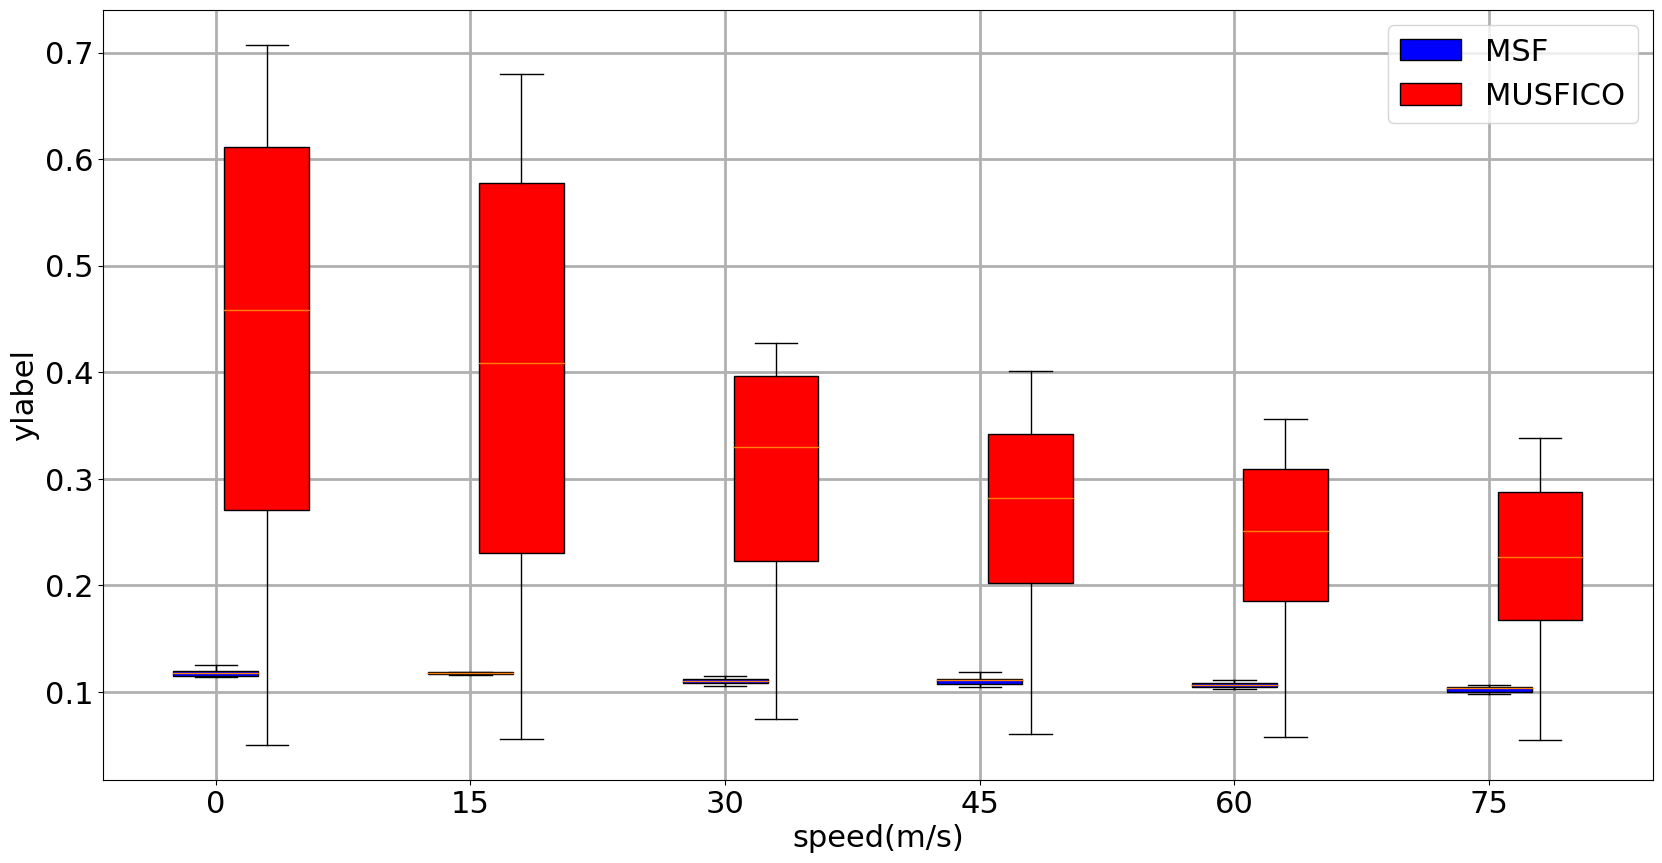

In [14]:
plot_resource_boxplot(cpu)

# Coutourf plot

In [12]:
def contourf_treat(df):
    data = df.transpose()
    data = pd.DataFrame(np.array_split(np.ravel(np.vstack(data.values).tolist()), 2)).transpose()
    data.columns = ["dp", "musfico"]
    data_dp, data_musfico = (
        pd.DataFrame(np.array_split(data["dp"].values, 6)),
        pd.DataFrame(np.array_split(data["musfico"].values, 6)),
    )
    # data_f = pd.concat([data_dp,data_musfico],axis=0)
    data_dp.index = [75.0, 60.0, 45.0, 30.0, 15.0, 0.0]
    data_musfico.index = [75.0, 60.0, 45.0, 30.0, 15.0, 0.0]
    return data_dp, data_musfico

In [13]:
dp, musfico = contourf_treat(acceptance)

In [22]:
dp_min = np.min(dp.values)
dp_max = np.max(dp.values)
ms_min = np.min(musfico.values)
ms_max = np.max(musfico.values)
zmin = dp_min if dp_min < ms_min else ms_min
zmax = dp_max if dp_max > ms_max else ms_max

In [15]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dados de exemplo
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [75, 60, 45, 30, 15, 0]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("dp", "musfico"),
)

fig.add_trace(go.Contour(x=x, y=y, z=dp.values, zmin=zmin, zmax=zmax), 1, 1)

fig.add_trace(go.Contour(x=x, y=y, z=musfico.values, zmin=zmin, zmax=zmax), 1, 2)

fig.update_layout(
    xaxis={"title": "Sessions"}, yaxis={"title": "Speed"}, title={"text": "Acceptance"}
)

fig.show()

# 3D plots

In [46]:
import plotly.graph_objects as go

import pandas as pd

# Read data from a csv
z_musfico = musfico.values
z_dp = dp.values
fig = go.Figure(
    data=[
        go.Surface(x=x, y=y, z=z_musfico, cmin=zmin, cmax=zmax, name="Musfico Surface"),
        go.Surface(x=x, y=y, z=z_dp, cmin=zmin, cmax=zmax, name="dp Surface"),
    ]
)

fig.update_traces(contours_z=dict(show=False, usecolormap=True, highlightcolor="limegreen"))

fig.update_layout(
    title="Acceptance",
    autosize=False,
    scene_camera_eye=dict(x=1.87, y=0.88, z=-0.64),
    width=500,
    height=500,
    scene=dict(xaxis_title="Sessions", yaxis_title="Speed(km/h)", zaxis_title="Acceptance"),
)


fig.show()

In [48]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import numpy as np

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"is_3d": True}, {"is_3d": True}]],
    subplot_titles=["dp", "musfico"],
)

fig.add_trace(go.Surface(x=x, y=y, z=z_dp, cmin=zmin, cmax=zmax), 1, 1)
fig.add_trace(go.Surface(x=x, y=y, z=z_musfico, cmin=zmin, cmax=zmax), 1, 2)

fig.update_layout(title_text="Acceptance")
fig.show()